In [771]:
# Instalação de todas as dependências
!pip install scikit-learn pandas numpy optuna xgboost scipy shap matplotlib seaborn s3fs pyarrow

In [772]:
# ======================================
# IMPORTANDO BIBLIOTECAS
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualização da árvore
from sklearn.tree import plot_tree

# Normalização
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

#Métricas de classificação
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#Feature selection
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.feature_selection import RFECV

#Validação
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from scipy.stats import ks_2samp

#Validação cruzada
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import optuna
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint, loguniform

#SHAP
import shap

#Imputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer



# **Treino do modelo e métricas de validação**

In [773]:
# ======================================
# CONECTANDO NA GOLD (BASE DE DADOS)
# ======================================

# VARIAVEIS
s3_path_comparativo_metas_resultados = "s3://fiap-datalake-tech-public/gold/comparativo_metas_resultados/"


#ACESSO
dados = pd.read_parquet(
    s3_path_comparativo_metas_resultados,
    engine="pyarrow",
    storage_options={"anon": True}
)

dados.head(n=5)


,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3


In [774]:
pib_renda = pd.read_csv('pib_renda_gold.csv')

# # Filtra apenas colunas necessárias e remove duplicatas de id_municipio
pib_renda_unico = pib_renda[[
    'id_municipio',
    'pib_per_capita_R$',
    'renda_media_per_capita_R$',
    'densidade_demografica'
]].drop_duplicates(subset=['id_municipio'])

# Merge sem gerar linhas duplicadas
dados_mais_pib_renda = dados.merge(
    pib_renda_unico,
    on='id_municipio',
    how='left'
)
dados_mais_pib_renda.head()

,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,47065.679747,743.35,17.942874
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,49413.928396,343.73,1.599843
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,12680.615355,193.40,1.183025
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,12604.111612,200.40,2.116989


In [775]:
# ======================================
# IMPUTER TRANSFORMER
# ======================================

#Colunas de meta_ano e desvio_ano não possuem valores para 2023 porque foi o primeiro ano da pesquisa (sem meta para aquele ano específico porque começou naquele momento)

imputer_num = SimpleImputer(strategy='median')

# Aplica apenas nas colunas numéricas
dados_nulos = ['renda_media_per_capita_R$','pib_per_capita_R$','densidade_demografica']
dados_mais_pib_renda[dados_nulos] = imputer_num.fit_transform(dados_mais_pib_renda[dados_nulos])

dados_mais_pib_renda.head()


,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,47065.679747,743.35,17.942874
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,49413.928396,343.73,1.599843
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,12680.615355,193.40,1.183025
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,12604.111612,200.40,2.116989


In [776]:
# ======================================
# FEATURE ENGINEERING
# ======================================
#Foi feita na Gold porque na Silver só tínhamos a meta do municipio e a taxa real, na Gold calculamos o desvio entre a meta e realidade.

#Porém, como estamos trabalhando com dados de 2023, 2024 e 2025, vamos trabalhar com séries temporais. Como nossa amostragem é de apenas 3 anos, ao tentar decompor nosso dataset nos deparamos com a dificuldade de aplicar um período ideal na biblioteca de statsmodel, para aplicar 2, teríamos que ter pelo menos 4 observações, e nós extraímos a média por ano de 3 anos, ou seja, nossa amostragem era insuficiente.
#Para o ADF também tivemos problemas por conta da amostragem pequena também.
#Com isso, como nosso dataframe possui dados temporais e o algoritmo não tem a capacidade de interpretá-lo de maneira sequencial (temporal), vamos utilizar séries temporais para utilizá-los corretamente no nosso modelo, de forma que não tenha data leakege, onde o modelo poderia prever o "passado utilizando o futuro", com dados de 2025 na previsão de 2025, por exemplo.

# 1. Garantir a ordenação temporal correta por município
dados_mais_pib_renda = dados_mais_pib_renda.sort_values(
    by=["id_municipio", "ano"]
).reset_index(drop=True)

# Criar lag_1 (valor do ano anterior: t-1) e lag_2 e diff
dados_mais_pib_renda["lag_1"] = dados_mais_pib_renda.groupby("id_municipio")[
    "taxa_alfabetizacao_real"
].shift(1)

dados_mais_pib_renda['diff_1'] = dados_mais_pib_renda['taxa_alfabetizacao_real'].diff(1)

# Criar média móvel dos 2 anos anteriores (shift(1) evita vazamento do ano corrente)
dados_mais_pib_renda["rolling_mean_2"] = (
    dados_mais_pib_renda.groupby("id_municipio")["taxa_alfabetizacao_real"]
    .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())
)

dados_mais_pib_renda.head()



,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica,lag_1,diff_1,rolling_mean_2
0,2023,RO,1100015,Alta Floresta D'Oeste,227,67.40,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,48803.311567,476.99,3.033819,NaN,NaN,NaN
1,2024,RO,1100015,Alta Floresta D'Oeste,275,68.00,67.08,0.92,Atingiu a Meta,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,48803.311567,476.99,3.033819,67.40,0.60,67.40
2,2025,RO,1100015,Alta Floresta D'Oeste,270,78.15,69.51,8.64,Atingiu a Meta,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,48803.311567,476.99,3.033819,68.00,10.15,67.70
3,2023,RO,1100023,Ariquemes,1222,62.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,45592.551377,689.95,21.719449,NaN,-15.63,NaN
4,2024,RO,1100023,Ariquemes,1066,65.85,65.22,0.63,Atingiu a Meta,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,45592.551377,689.95,21.719449,62.52,3.33,62.52


In [777]:
# ======================================
# FEATURE EXTRACTION
# ======================================

#Para chegarmos no Status Meta (com as classes "atingiu" ou "não atingiu") utilizamos o desvio, se era >=0 o municipio atingiu, se não, não atingiu a meta.
# O feature extraction ajudou a não ter no modelo duas features que não agregariam (meta_ano e desvio_ano) e que poderiam gerar associações espúrias e aumentar a dimensionalidade.

# Criar agregação por UF para ajudar no feature engineering já que a adição de taxa_alfabetizacao_real gera data leakage
dados_mais_pib_renda['media_alfa_uf'] = dados_mais_pib_renda.groupby('sigla_uf')['taxa_alfabetizacao_real'].transform('mean')

#Filtrar 2023 já que status meta é "Sem meta definida" e gera muito resíduo na nossa base na etapa de KNN dos lags, e alé disso, quando incluído, apresentava um F1 score de 0.16 com apenas 211 ocorrências (support)
status_desejados = ["Abaixo da Meta", "Atingiu a Meta"]
dados_mais_pib_renda = dados_mais_pib_renda[dados_mais_pib_renda['status_meta'].isin(status_desejados)].copy()
dados_mais_pib_renda.head()



,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica,lag_1,diff_1,rolling_mean_2,media_alfa_uf
1,2024,RO,1100015,Alta Floresta D'Oeste,275,68.00,67.08,0.92,Atingiu a Meta,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,48803.311567,476.99,3.033819,67.40,0.60,67.400,71.482949
2,2025,RO,1100015,Alta Floresta D'Oeste,270,78.15,69.51,8.64,Atingiu a Meta,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,48803.311567,476.99,3.033819,68.00,10.15,67.700,71.482949
4,2024,RO,1100023,Ariquemes,1066,65.85,65.22,0.63,Atingiu a Meta,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,45592.551377,689.95,21.719449,62.52,3.33,62.520,71.482949
5,2025,RO,1100023,Ariquemes,1325,79.70,68.02,11.68,Atingiu a Meta,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,45592.551377,689.95,21.719449,65.85,13.85,64.185,71.482949
7,2024,RO,1100031,Cabixi,75,76.00,70.85,5.15,Atingiu a Meta,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,56219.772005,457.17,4.072298,71.05,4.95,71.050,71.482949


In [778]:
# ============================================================================================
# DEFININDO X e y e divisão treino e teste (Temporal: 2023-2024 -> Treino | 2025 -> Teste)
# ============================================================================================

#Definição do y
y_bruto = dados_mais_pib_renda['status_meta']

#Definição do X
colunas_X = [
    'ano',
    'lag_1',
    'diff_1',
    'rolling_mean_2',
    'total_avaliados',
    'media_alfa_uf',
    'sigla_uf',
    'renda_media_per_capita_R$',
    'pib_per_capita_R$',
    'densidade_demografica',
]
X_bruto = dados_mais_pib_renda[colunas_X]

#Feature encoding do X
  # Aplicar One-Hot Encoding en sigla_uf (Estado)
X = pd.get_dummies(X_bruto, columns=['sigla_uf'], drop_first=True, dtype=int)

#Divisão Treino (2024) e Teste (2025) baseada no ano
mascara_treino = X['ano'].isin([2024])
mascara_teste = X['ano'] == 2025

X_train = X[mascara_treino].copy()
X_test = X[mascara_teste].copy()
y_train = y_bruto[mascara_treino].copy()
y_test = y_bruto[mascara_teste].copy()

# Salvar metadados dos municípios de 2025 para a tabela final de comparação
df_resultado_2025 = dados_mais_pib_renda[mascara_teste][
    ["id_municipio", "nome_municipio", "sigla_uf", "status_meta"]
].copy()

#Remoção de coluna que não deve ir pro modelo
X_train = X_train.drop(columns=['ano']).reset_index(drop=True)
X_test = X_test.drop(columns=['ano']).reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

#Imputer transformation - Lags
#flag keep_empty_features=True ativada, preenchendo-a temporariamente com um valor padrão como 0 em vez de apagar os dados de 2023 que podem ser úteis para a generalização do modelo.
colunas_para_imputar = ['lag_1', 'diff_1', 'rolling_mean_2']

knn_imputer = KNNImputer(n_neighbors=5, weights='uniform',keep_empty_features=True)

  # Guarda as colunas originais do X_train
colunas_X = X_train.columns

  # Fit e transform em TODO o X_train
X_train_imputed = knn_imputer.fit_transform(X_train)

  # Transform em TODO o X_test
X_test_imputed = knn_imputer.transform(X_test)

  # Recria os DataFrames
X_train = pd.DataFrame(X_train_imputed, columns=colunas_X, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=colunas_X, index=X_test.index)

#Feature encoding do y
le_y = LabelEncoder()
  # O fit é feito APENAS no treino
y_train_encoded = le_y.fit_transform(y_train)
  # O teste é apenas transformado (usando o mapeamento aprendido no treino)
y_test_encoded = le_y.transform(y_test)

# Escalonamento do X (Fit no treino, transform no treino e teste)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#Utilizamos o StandardScale (desvio padrão) porque é indicado para Regressão Logística, já que não temos tantos outliers no conjunto de dados para justificar o uso do Robust Scaling

# ======================================
# FEATURE SELECTION: SELECT KBEST
# ======================================

# Mutual Information (escolhida porque é mais versátil, permitindo qualquer feature categórica ou não. Apesar do dataset não ser grande (não possui milhares de observações), a seleção de features vai nos ajudar na interpretabilidade)
selector = SelectKBest(mutual_info_classif, k=20)

# Fit e transform no conjunto de treino escalonado
X_train_selected = selector.fit_transform(X_train_scaled, y_train_encoded)

# Apenas transform no conjunto de teste
X_test_selected = selector.transform(X_test_scaled)

# Verificar quais features foram selecionadas
selected_names = X_train.columns[selector.get_support()]
print('Features selecionadas (Mutual Info):', selected_names.tolist())

print('Treino:', X_train_selected.shape)
print('Teste:', X_test_selected.shape)


Features selecionadas (Mutual Info): ['lag_1', 'diff_1', 'rolling_mean_2', 'media_alfa_uf', 'renda_media_per_capita_R$', 'sigla_uf_AL', 'sigla_uf_BA', 'sigla_uf_CE', 'sigla_uf_GO', 'sigla_uf_MA', 'sigla_uf_MG', 'sigla_uf_MS', 'sigla_uf_MT', 'sigla_uf_PA', 'sigla_uf_PE', 'sigla_uf_PR', 'sigla_uf_RJ', 'sigla_uf_RN', 'sigla_uf_RS', 'sigla_uf_TO']
Treino: (5232, 20)
Teste: (5345, 20)


Chegamos a utilizar o wrapper RFECV que encontra o ponto ótimo via validação cruzada, ele escolheu 27 features invés de 10 com selectkbest, teve uma ótima acurácia também: 0.8492, porém, demorou muito mais do que o selectkbest. Ou seja, tem um custo computacional maior.

In [779]:
# # =============================================================================
# # TREINAMENTO COM REGRESSÃO LOGÍSTICA (OTIMIZADO COM RANDOMIZED SEARCH CV)
# # =============================================================================
# 1. Definir o espaço de busca com distribuições contínuas

tscv = TimeSeriesSplit(n_splits=4)

param_dist = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
    'penalty': ['l1'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [3000]
}

# 2. Instanciar a Regressão Logística
modelo = LogisticRegression(class_weight='balanced',random_state=42)

# 3. Instanciar o RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=modelo,
    param_distributions=param_dist,
    n_iter=50,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 4. Executar a busca nos dados normalizados
random_search.fit(X_train_selected, y_train_encoded)

# 5. Exibir os resultados
print(f"Melhor score (Validação Cruzada): {random_search.best_score_:.4f}")
print("Melhores Hiperparâmetros:", random_search.best_params_)

Fitting 4 folds for each of 14 candidates, totalling 56 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 14 is smaller than n_iter=50. Running 14 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Melhor score (Validação Cruzada): 0.8960
Melhores Hiperparâmetros: {'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 3000, 'C': 0.05}


Usamos regressão logística porque inicialmente pensamos na possibilidade de usar probabilidade (qual a probabilidade de que esse municipio atinja a meta em 2026, 2027, 2028, 2029 e 2030?), de forma que a explicabilidade fosse mais facilitada.

Como nosso dataset é pequeno, e com pouca dimensionalidade, optamos pro um modelo que utiliza poucos recursos computacionais.

Além disso, optamos por Randomized Search CV por ter um custo mais controlado, já que o Grid Search demorou muito mais para processar e seu score teve um resultado de otimização quase irrosório.

=== COMPARAÇÃO REALIDADE VS ESTIMADO (2025) ===
           nome_municipio sigla_uf     status_meta status_meta_estimado  \
2   Alta Floresta D'Oeste       RO  Atingiu a Meta       Atingiu a Meta   
5               Ariquemes       RO  Atingiu a Meta       Atingiu a Meta   
8                  Cabixi       RO  Atingiu a Meta       Atingiu a Meta   
11                 Cacoal       RO  Atingiu a Meta       Atingiu a Meta   
14             Cerejeiras       RO  Atingiu a Meta       Atingiu a Meta   
17      Colorado do Oeste       RO  Atingiu a Meta       Atingiu a Meta   
20             Corumbiara       RO  Atingiu a Meta       Atingiu a Meta   
23          Costa Marques       RO  Abaixo da Meta       Atingiu a Meta   
26        Espigão D'Oeste       RO  Atingiu a Meta       Atingiu a Meta   
29          Guajará-Mirim       RO  Atingiu a Meta       Atingiu a Meta   

    probabilidade_confianca  acertou  
2                  0.912467     True  
5                  0.956060     True  
8        

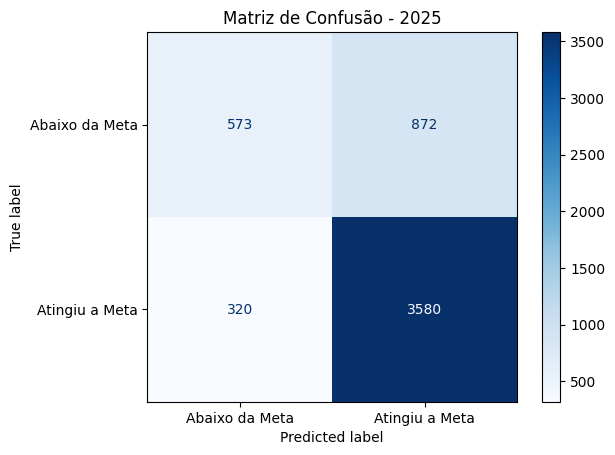

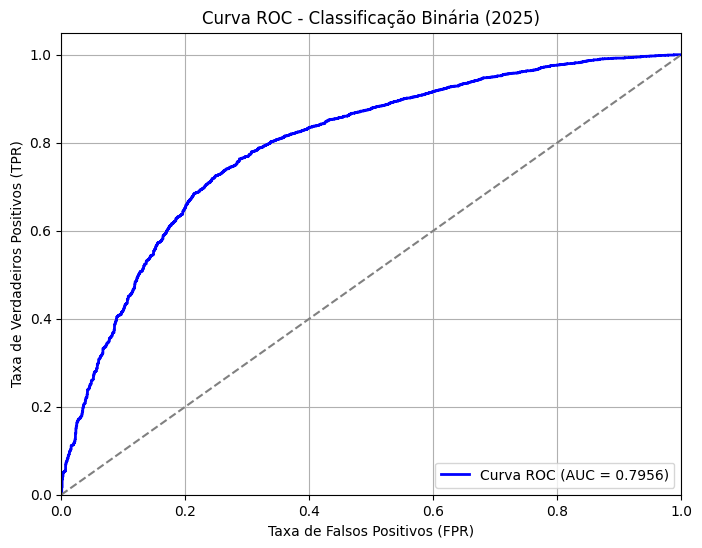

ROC AUC Score Geral: 0.7956


In [780]:
# ===============================================================
# MÉTRICAS DE AVALIAÇÃO (MODELO OTIMIZADO RANDOMIZED SEARCH CV)
# ===============================================================

# 1. Obter o melhor modelo ajustado no RandomizedSearch
melhor_modelo = random_search.best_estimator_

# 2. Obter probabilidades no conjunto de teste (2025)
y_prob_matrix = melhor_modelo.predict_proba(X_test_selected)

# 3. Probabilidade da Classe 1 (Positiva)
y_prob_pos = y_prob_matrix[:, 1]

# 4. Aplicação do Threshold de Decisão Customizado (Gera array 1D com 0 ou 1)
threshold = 0.40
y_pred_encoded = (y_prob_pos >= threshold).astype(int)

# 5. Decodificar rótulos previstos para texto ('Atingiu a Meta', 'Abaixo da Meta', etc.)
df_resultado_2025["status_meta_estimado"] = le_y.inverse_transform(y_pred_encoded)

# 6. Adicionar a probabilidade de confiança do modelo (Maior valor entre as classes)
df_resultado_2025["probabilidade_confianca"] = y_prob_matrix.max(axis=1)

# 7. Flag de acerto
df_resultado_2025["acertou"] = (
    df_resultado_2025["status_meta"] == df_resultado_2025["status_meta_estimado"]
)

# Visualizar comparação dos primeiros 10 municípios
print("=== COMPARAÇÃO REALIDADE VS ESTIMADO (2025) ===")
print(
    df_resultado_2025[
        [
            "nome_municipio",
            "sigla_uf",
            "status_meta",
            "status_meta_estimado",
            "probabilidade_confianca",
            "acertou",
        ]
    ].head(10)
)

# Taxa global de acertos no ano de 2025
acuracia_2025 = df_resultado_2025["acertou"].mean()
print(f"\nAcurácia geral do modelo para 2025: {acuracia_2025:.2%}\n")



# AVALIAÇÃO DAS MÉTRICAS DE CLASSIFICAÇÃO


# 1. Métricas gerais resumidas (Média Ponderada)
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
precision_weighted = precision_score(y_test_encoded, y_pred_encoded, average='weighted')
recall_weighted = recall_score(y_test_encoded, y_pred_encoded, average='weighted')
f1_weighted = f1_score(y_test_encoded, y_pred_encoded, average='weighted')

print(f"Acurácia Geral:         {accuracy:.4f}")
print(f"Precisão (Weighted):    {precision_weighted:.4f}")
print(f"Recall (Weighted):      {recall_weighted:.4f}")
print(f"F1-Score (Weighted):    {f1_weighted:.4f}\n")

# 2. Visão detalhada por classe
print("--- Relatório Completo por Classe ---")
print(classification_report(y_test_encoded, y_pred_encoded))

# 3. Matriz de Confusão
matriz = confusion_matrix(y_test_encoded, y_pred_encoded)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=le_y.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - 2025")
plt.show()

# 4. Curva ROC (Binária para a classe positiva)
auc_score_geral = roc_auc_score(y_test_encoded, y_prob_pos)
fpr, tpr, thresholds_roc = roc_curve(y_test_encoded, y_prob_pos)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Linha de aleatoriedade

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Classificação Binária (2025)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f'ROC AUC Score Geral: {auc_score_geral:.4f}')

# **Validações e otimizações**

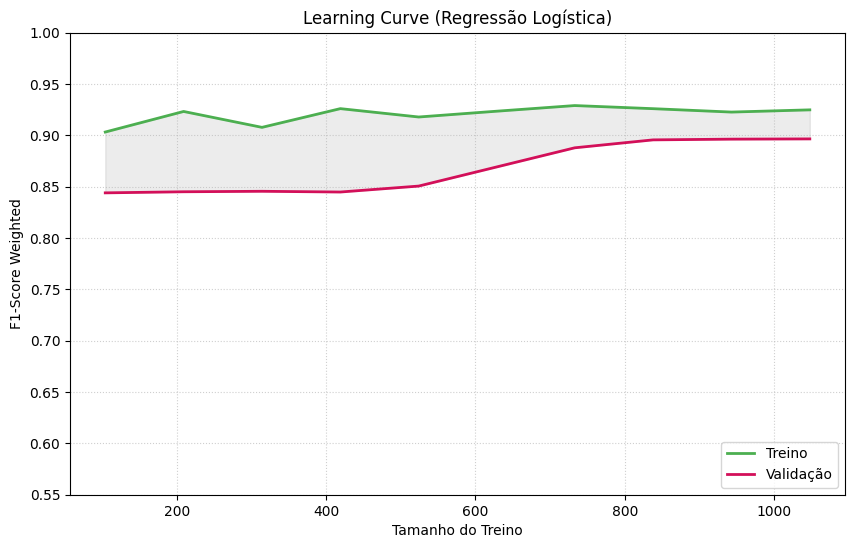

Diagnóstico Learning Curves: BOM AJUSTE
Ação sugerida: O modelo generaliza bem!
F1-Score na Validação: 0.8966
Gap Treino-Validação: 0.0283



In [781]:
##Learning Curves e Validation Curves

# 1. Learning Curves com a métrica (f1_weighted)
train_sizes, train_scores, val_scores = learning_curve(
    melhor_modelo,
    X_train_selected,
    y_train_encoded,
    cv=tscv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_weighted',
    n_jobs=-1
)

# 2. Média das métricas (sem o sinal de menos '-')
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# 3. Visualização da Curva de Aprendizado
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Treino', color='#4CAF50', lw=2)
plt.plot(train_sizes, val_mean, label='Validação', color='#D30F59', lw=2)
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.15, color='gray')

plt.xlabel('Tamanho do Treino')
plt.ylabel('F1-Score Weighted')
plt.title('Learning Curve (Regressão Logística)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0.55, 1.0)
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Diagnóstico Automático com Learning Curves
gap = train_mean[-1] - val_mean[-1]

if val_mean[-1] < 0.70 and gap < 0.05:
    diagnosis = 'UNDERFITTING'
    action = 'Aumente a complexidade das features (ex: PolynomialFeatures) ou diminua a regularização (aumente o C).'
elif gap > 0.10:
    diagnosis = 'OVERFITTING'
    action = 'Aumente a regularização (diminua o C), aplique seleção de features ou adicione mais dados.'
else:
    diagnosis = 'BOM AJUSTE'
    action = 'O modelo generaliza bem!'

print(f'Diagnóstico Learning Curves: {diagnosis}')
print(f'Ação sugerida: {action}')
print(f'F1-Score na Validação: {val_mean[-1]:.4f}')
print(f'Gap Treino-Validação: {gap:.4f}\n')

# #Validation Curves
# param_range = range(1, 21)
# tr_s, val_s = validation_curve(
#     RandomForestRegressor(n_estimators=50, random_state=42),
#     X_train_scaled, y_train,
#     param_name='max_depth', param_range=param_range,
#     cv=5, scoring='neg_mean_squared_error', n_jobs=-1
# )

# train_mean = -tr_s.mean(axis=1)
# val_mean = -val_s.mean(axis=1)
# best_depth = list(param_range)[np.argmin(val_mean)]

# plt.figure(figsize=(10, 6))
# plt.plot(param_range, train_mean, label='Treino',
#          color='#4CAF50')
# plt.plot(param_range, val_mean, label='Validação',
#          color='#D30F59')
# plt.axvline(best_depth, color='#FFD54F', linestyle='--',
#             label=f'Melhor max_depth={best_depth}')
# plt.xlabel('max_depth')
# plt.ylabel('Erro (MSE)')
# plt.legend()
# plt.title('Validation Curve')
# print(f'Melhor max_depth: {best_depth}')

# #Complexidade crescente (polinômios de grau 1 a 20)
# degrees = [1, 2, 3, 5, 10, 20]
# for deg in degrees:
#     model = Pipeline([
#         ('poly', PolynomialFeatures(deg)),
#         ('lin', LinearRegression())
#     ])
#     model.fit(X_train_scaled, y_train)
#     tr_err = mean_squared_error(y_train, model.predict(X_train_scaled))
#     te_err = mean_squared_error(y_test, model.predict(X_test_scaled))

#     status = ('UNDERFITTING' if tr_err > 0.5 and te_err > 0.5
#               else 'OVERFITTING' if te_err > tr_err * 2
#               else 'BOM AJUSTE')
#     print(f'Grau {deg:2d} | Treino={tr_err:.3f} | '
#           f'Teste={te_err:.3f} | {status}')



In [782]:
# ===============================================================
# SHAP PARA EXPLICABILIDADE
# ===============================================================

## Usando dataframe não escalonado para melhorar rótulos de waterfall plot
# 1. Nomes das 15 features selecionadas pelo SelectKBest
selected_cols = X.columns[selector.get_support()].tolist()

# 2. DataFrame ESCALONADO com as features selecionadas (usado pelo modelo)
X_train_scaled_df = pd.DataFrame(
    X_train_selected, columns=selected_cols, index=X_train.index
)
X_test_scaled_df = pd.DataFrame(
    X_test_selected, columns=selected_cols, index=X_test.index
)

# 3. DataFrame ORIGINAL (não-escalonado) apenas com as features selecionadas (usado para exibições no SHAP)
X_test_raw_df = X_test[selected_cols].copy()



##Criando visuais SHAP

# 4. Modelo final do treino
modelo_final = random_search.best_estimator_

# 5. Criar o explainer com os dados de treino escalonados
masker = shap.maskers.Independent(
    X_train_scaled_df, max_samples=len(X_train_scaled_df)
)
explainer = shap.LinearExplainer(modelo_final, masker)

# 6. Calcular a explicação baseada no teste ESCALONADO
explanation = explainer(X_test_scaled_df)

# Ajuste para pegar a classe positiva (índice 1) em classificação binária
if len(explanation.shape) == 3:
    explanation_classe = explanation[:, :, 1]
    shap_values_classe = explanation[:, :, 1].values
    expected_val = (
        explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value
    )
else:
    explanation_classe = explanation
    shap_values_classe = explanation.values
    expected_val = explainer.expected_value


# ===============================================================
# 5. VISÃO GLOBAL (Summary Plot com valores originais)
# ===============================================================
print("Summary Plot (Beeswarm) - Valores Originais")
# Passando X_test_raw_df no argumento das cores, a barra exibe a escala real da variável
shap.summary_plot(explanation_classe, X_test_raw_df)

print("Summary Plot (Bar)")
shap.summary_plot(explanation_classe, X_test_raw_df, plot_type="bar")


# ===============================================================
# 6. DEPENDENCE PLOTS (Com eixos X exibindo valores originais)
# ===============================================================
print("Dependence plots - Valores Originais")

# Seleciona as Top 6 variáveis mais importantes
mean_abs_shap = np.abs(shap_values_classe).mean(axis=0)
top_features = (
    pd.Series(mean_abs_shap, index=selected_cols)
    .sort_values(ascending=False)
    .head(6)
    .index
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), top_features):
    # Passar X_test_raw_df faz o eixo X exibir os anos reais (ex: 2023, 2024, 2025)
    shap.dependence_plot(
        feat,
        shap_values_classe,
        X_test_raw_df,
        ax=ax,
        show=False,
    )
    ax.set_title(f"Dependência: {feat}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("dependence_grid_valores_reais.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# ===============================================================
# 7. WATERFALL PLOTS (Exibindo 2024, 59.66, etc., no eixo esquerdo)
# ===============================================================
print("Waterfall plots - Valores Originais")

for idx in [0, 10, 50]:
    # Construímos o Explanation manualmente combinando os SHAP values do modelo com os dados RAW
    exp_raw = shap.Explanation(
        values=explanation_classe[idx].values,
        base_values=explanation_classe[idx].base_values,
        data=X_test_raw_df.iloc[
            idx
        ].values,  # AQUI está o truque: exibe o valor real!
        feature_names=selected_cols,
    )

    plt.figure(figsize=(8, 6))
    shap.waterfall_plot(exp_raw, show=False)
    plt.title(f"Instância índice {idx}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"waterfall_idx_{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


# ===============================================================
# 8. DECISION PLOT
# ===============================================================
print("Decision plot")
n_samples = min(100, len(X_test_raw_df))

plt.figure(figsize=(10, 6))
shap.decision_plot(
    expected_val,
    shap_values_classe[:n_samples],
    X_test_raw_df.iloc[:n_samples],  # Mostra rótulos/valores brutos nas linhas
    show=False,
)
plt.tight_layout()
plt.savefig("decision_plot.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 33 but size of corresponding boolean axis is 32